In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

DATASET_PATH = Path("../data/synthetic/synthetic_year.csv")

In [2]:
df = pd.read_csv(DATASET_PATH)
df.head()

,profile_name,day_index,hour,temp_air_c,hr_pct,solar_wm2,pv_voltage,temp_collector_c,temp_cond_c,delta_hr_sorbent,reservoir_level_pct,soc_battery_pct,dew_point_c,humidity_ratio_gkg,vcrc_state,vcrc_reason,sorbent_mode,heater_on,sorbent_saturated
0,dakar_coastal,0,0,18.42,67.72,0.0,0.0,18.26,13.90,2.39,11.125484,70.577072,12.343953,8.929718,1,eligible,absorption,False,False
1,dakar_coastal,0,1,17.25,71.46,0.0,0.0,16.69,13.80,2.72,12.518850,63.882427,12.041524,8.750818,1,eligible,absorption,False,False
2,dakar_coastal,0,2,16.33,71.10,0.0,0.0,17.25,12.65,1.31,13.717395,56.688926,11.081749,8.205504,1,eligible,absorption,False,False
3,dakar_coastal,0,3,16.70,73.81,0.0,0.0,16.78,14.22,1.12,14.905522,49.585642,12.003688,8.728459,1,eligible,absorption,False,False
4,dakar_coastal,0,4,16.96,72.79,0.0,0.0,17.37,13.16,0.11,16.098170,42.937683,12.042814,8.751423,1,eligible,regeneration,True,True


## Preliminaires

In [3]:
df.shape, df.columns.tolist()

((8760, 19),
 ['profile_name',
  'day_index',
  'hour',
  'temp_air_c',
  'hr_pct',
  'solar_wm2',
  'pv_voltage',
  'temp_collector_c',
  'temp_cond_c',
  'delta_hr_sorbent',
  'reservoir_level_pct',
  'soc_battery_pct',
  'dew_point_c',
  'humidity_ratio_gkg',
  'vcrc_state',
  'vcrc_reason',
  'sorbent_mode',
  'heater_on',
  'sorbent_saturated'])

In [4]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
profile_name,8760,1,dakar_coastal,8760,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_index,8760.0,NaN,NaN,NaN,182.0,105.372043,0.0,91.0,182.0,273.0,364.0
hour,8760.0,NaN,NaN,NaN,11.5,6.922582,0.0,5.75,11.5,17.25,23.0
temp_air_c,8760.0,NaN,NaN,NaN,25.640951,4.540016,15.69,22.19,25.63,29.11,35.46
hr_pct,8760.0,NaN,NaN,NaN,67.679725,12.779055,35.12,58.6,67.38,77.77,96.67
solar_wm2,8760.0,NaN,NaN,NaN,171.913967,215.78312,0.0,0.0,0.0,353.075,706.24
pv_voltage,8760.0,NaN,NaN,NaN,5.459526,5.833866,0.0,0.0,2.75,11.0625,16.63
temp_collector_c,8760.0,NaN,NaN,NaN,30.867051,9.650529,15.1,22.74,28.32,40.24,51.76
temp_cond_c,8760.0,NaN,NaN,NaN,22.916796,4.389735,11.93,19.6675,22.84,26.17,33.08
delta_hr_sorbent,8760.0,NaN,NaN,NaN,1.170271,1.44109,0.0,0.0,0.53,2.07,6.27


## Distributions

In [5]:
numeric_columns = [
    "temp_air_c",
    "hr_pct",
    "solar_wm2",
    "pv_voltage",
    "temp_collector_c",
    "temp_cond_c",
    "delta_hr_sorbent",
    "reservoir_level_pct",
    "soc_battery_pct",
    "dew_point_c",
    "humidity_ratio_gkg",
]

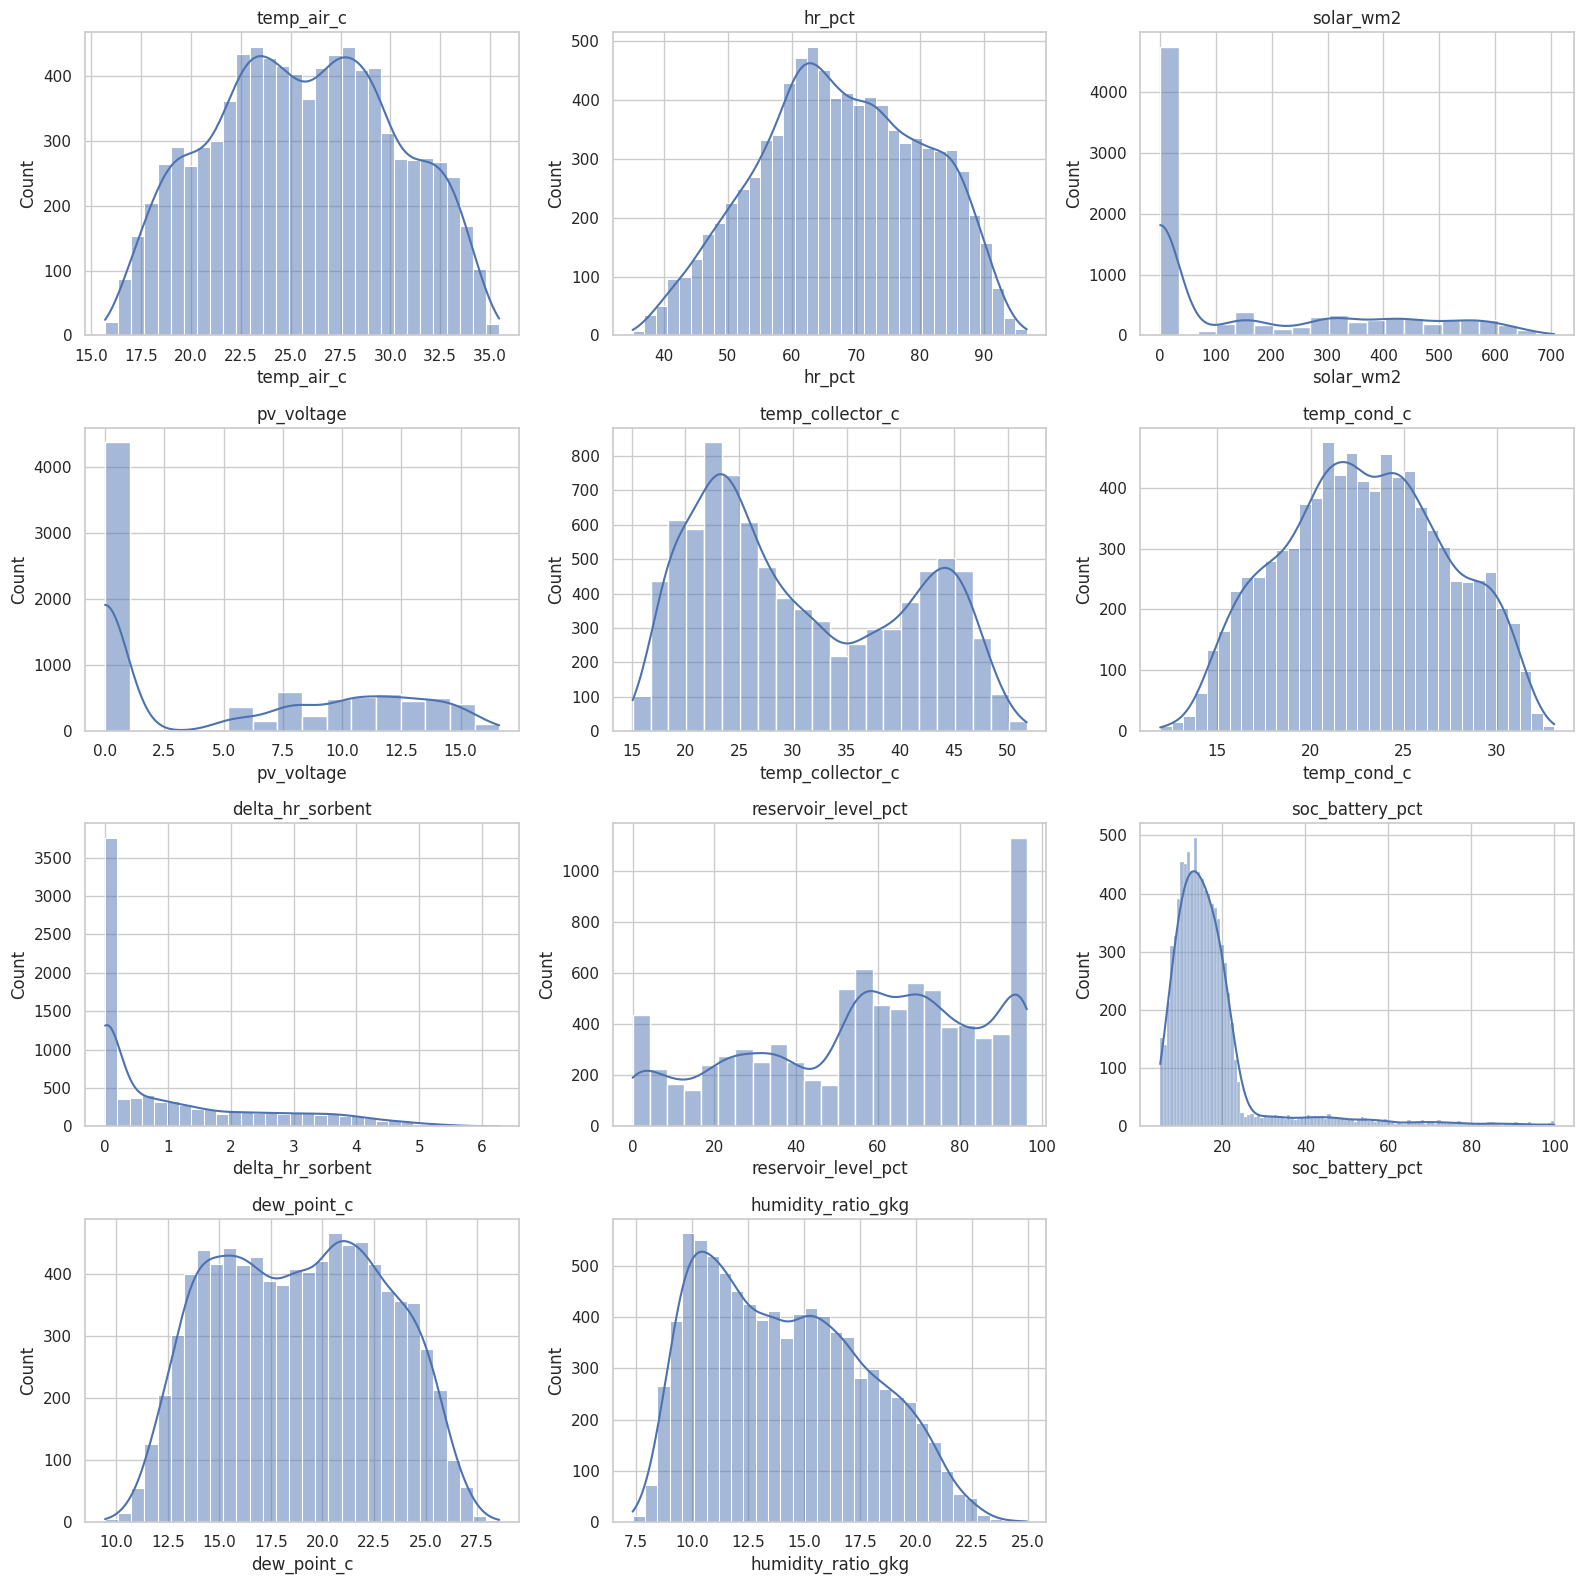

In [6]:
fig, axes = plt.subplots(4, 3, figsize=(16, 16))
for ax, column in zip(axes.flat, numeric_columns):
    sns.histplot(df[column], kde=True, ax=ax)
    ax.set_title(column)

for ax in axes.flat[len(numeric_columns):]:
    ax.axis("off")

plt.tight_layout()

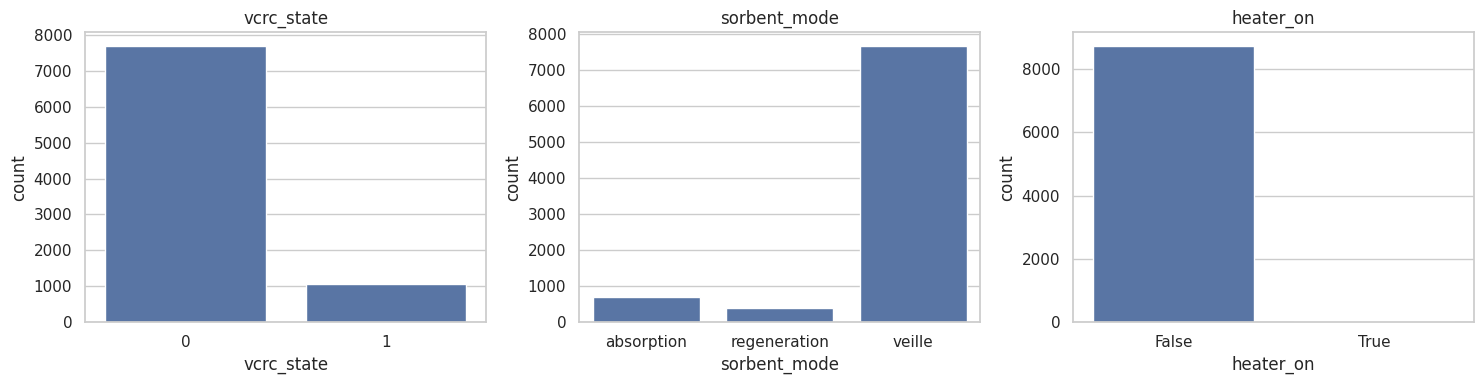

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=df, x="vcrc_state", ax=axes[0])
sns.countplot(data=df, x="sorbent_mode", order=sorted(df["sorbent_mode"].unique()), ax=axes[1])
sns.countplot(data=df, x="heater_on", ax=axes[2])
axes[0].set_title("vcrc_state")
axes[1].set_title("sorbent_mode")
axes[2].set_title("heater_on")
plt.tight_layout()